In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np
import matplotlib.dates as mdates
import yaml

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools,interactive

In [5]:
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"

In [6]:
# Load YAML from a file
with open(yaml_path, 'r') as file:
    config = yaml.safe_load(file)

## 2. Create datasets for each glider mission containing MLD + other important variables for every profile

In [194]:
importlib.reload(tools)

ds_list = []
mld_ds_list = []
method = 'CR'
variable = 'SIGMA_1'
threshold = -3
use_bins = True
binning = 8

for glider in tqdm(config['gliders'], desc="Processing gliders"):
    glider_name = glider['name']
    
    for mission in glider['missions']:
        print(f"Processing glidermission: {mission['folder']}")
        folder = mission.get('folder')
        if folder == 'no folder':
            continue

        file_path = f"{destination_folder}/{folder}/all_data_OG1.nc"
        ds = xr.open_dataset(file_path)
        ds_list.append(ds)

        mld = tools.compute_mld(ds,variable=variable,method=method,threshold= threshold,ref_depth=10,use_bins=use_bins,binning=binning)
        # Add metadata
        mld['GLIDER_MISSION'] = folder
        mld['GLIDER'] = glider_name

        # Set TIME as index and convert to xarray.Dataset
        mld.set_index('TIME', inplace=True)
        mld_ds = xr.Dataset.from_dataframe(mld)

        mld_ds_list.append(mld_ds)
        
        mld_ds = mld_ds.sortby('TIME')
        ### somehow some time stamps are from 1970
        mld_ds = mld_ds.sel(TIME=slice('2006-01-01', '2009-12-31'))

Processing gliders:   0%|          | 0/9 [00:00<?, ?it/s]

Processing glidermission: 005/20080606
Processing glidermission: 005/20090829
Processing glidermission: 005/20081106


Processing gliders:  11%|█         | 1/9 [00:29<03:52, 29.09s/it]

Processing glidermission: 012/20070831


Processing gliders:  22%|██▏       | 2/9 [00:32<01:39, 14.24s/it]

...

Processing glidermission: no folder
Processing glidermission: 103/20070218
Processing glidermission: 103/20071113
Processing glidermission: 103/20090223


Processing gliders:  78%|███████▊  | 7/9 [02:32<00:51, 25.56s/it]

Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: 104/20070901
Processing glidermission: 104/20080214


Processing gliders: 100%|██████████| 9/9 [02:44<00:00, 18.29s/it]

Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder


In [195]:
importlib.reload(tools)
importlib.reload(plotting)

<module 'dissipationSML.plotting' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py'>

In [196]:
for i in range(len(mld_ds_list)):
    print(f"Processing glidermission: {str(mld_ds_list[i].GLIDER_MISSION[0].values)}")
    mld_ds_list[i] = tools.rms_in_mld(ds_list[i], mld_ds_list[i], ['VERTICAL_WATER_VELOCITY'],min_depth=0)
    mld_ds_list[i] = tools.mean_in_mld(ds_list[i], mld_ds_list[i], ['SIGTHETA','PSAL','TEMP'])

Processing glidermission: 005/20080606
Calculating RMS for VERTICAL_WATER_VELOCITY...


100%|██████████| 770/770 [00:07<00:00, 106.23it/s]


Computing mean for SIGTHETA in MLD


100%|██████████| 770/770 [00:07<00:00, 109.72it/s]


Computing mean for PSAL in MLD


...

100%|██████████| 224/224 [00:02<00:00, 97.22it/s]


Computing mean for PSAL in MLD


100%|██████████| 224/224 [00:02<00:00, 92.73it/s]


Computing mean for TEMP in MLD


100%|██████████| 224/224 [00:02<00:00, 95.76it/s]


In [198]:
### save each mld dataset to a netcdf file in the destination folder
for i in range(len(mld_ds_list)):
    folder = mld_ds_list[i].GLIDER_MISSION[0].values
    file_name = f"{destination_folder}/{folder}/alldata_mld.nc"
    ### check if file already exists
    if pathlib.Path(file_name).exists():
        print(f"File {file_name} already exists. Skipping...")
        continue
    else:
        # Save the dataset to a netCDF file
        mld_ds_list[i].to_netcdf(file_name)
        print(f"Saved {file_name}")

Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20090829/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/012/20070831/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/014/20080214/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/014/20080222/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/016/20061112/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/016/20071113/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/016/20080607/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/016/20090605/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/alldata_mld.nc
Saved /Users/tillmoritz/Desktop/Master_thesis/Data/Gli

In [221]:
### load all mld datasets from the destination folder
mld_ds_list = []
for glider in tqdm(config['gliders'], desc="Loading glider missions"):
    glider_name = glider['name']
    
    for mission in glider['missions']:
        print(f"Loading glidermission: {mission['folder']}")
        folder = mission.get('folder')
        if folder == 'no folder':
            continue

        file_path = f"{destination_folder}/{folder}/alldata_mld.nc"
        mld_ds = xr.open_dataset(file_path)
        mld_ds_list.append(mld_ds)

Loading glider missions:  56%|█████▌    | 5/9 [00:00<00:00, 41.93it/s]

Loading glidermission: 005/20080606
Loading glidermission: 005/20090829
Loading glidermission: 005/20081106
Loading glidermission: 012/20070831
Loading glidermission: 014/20080214
Loading glidermission: 014/20080222
Loading glidermission: 016/20061112
Loading glidermission: 016/20071113
Loading glidermission: 016/20080607
Loading glidermission: 016/20090605
Loading glidermission: 101/20061112
Loading glidermission: 101/20070609
Loading glidermission: 101/20081108
Loading glidermission: 102/20061112
Loading glidermission: no folder
Loading glidermission: 102/20071113
Loading glidermission: no folder
Loading glidermission: 103/20070218
Loading glidermission: 103/20071113
Loading glidermission: 103/20090223
Loading glidermission: no folder
Loading glidermission: no folder
Loading glidermission: 104/20070901


Loading glider missions: 100%|██████████| 9/9 [00:00<00:00, 42.44it/s]

Loading glidermission: 104/20080214
Loading glidermission: no folder
Loading glidermission: no folder
Loading glidermission: no folder
Loading glidermission: no folder
Loading glidermission: no folder
Loading glidermission: no folder


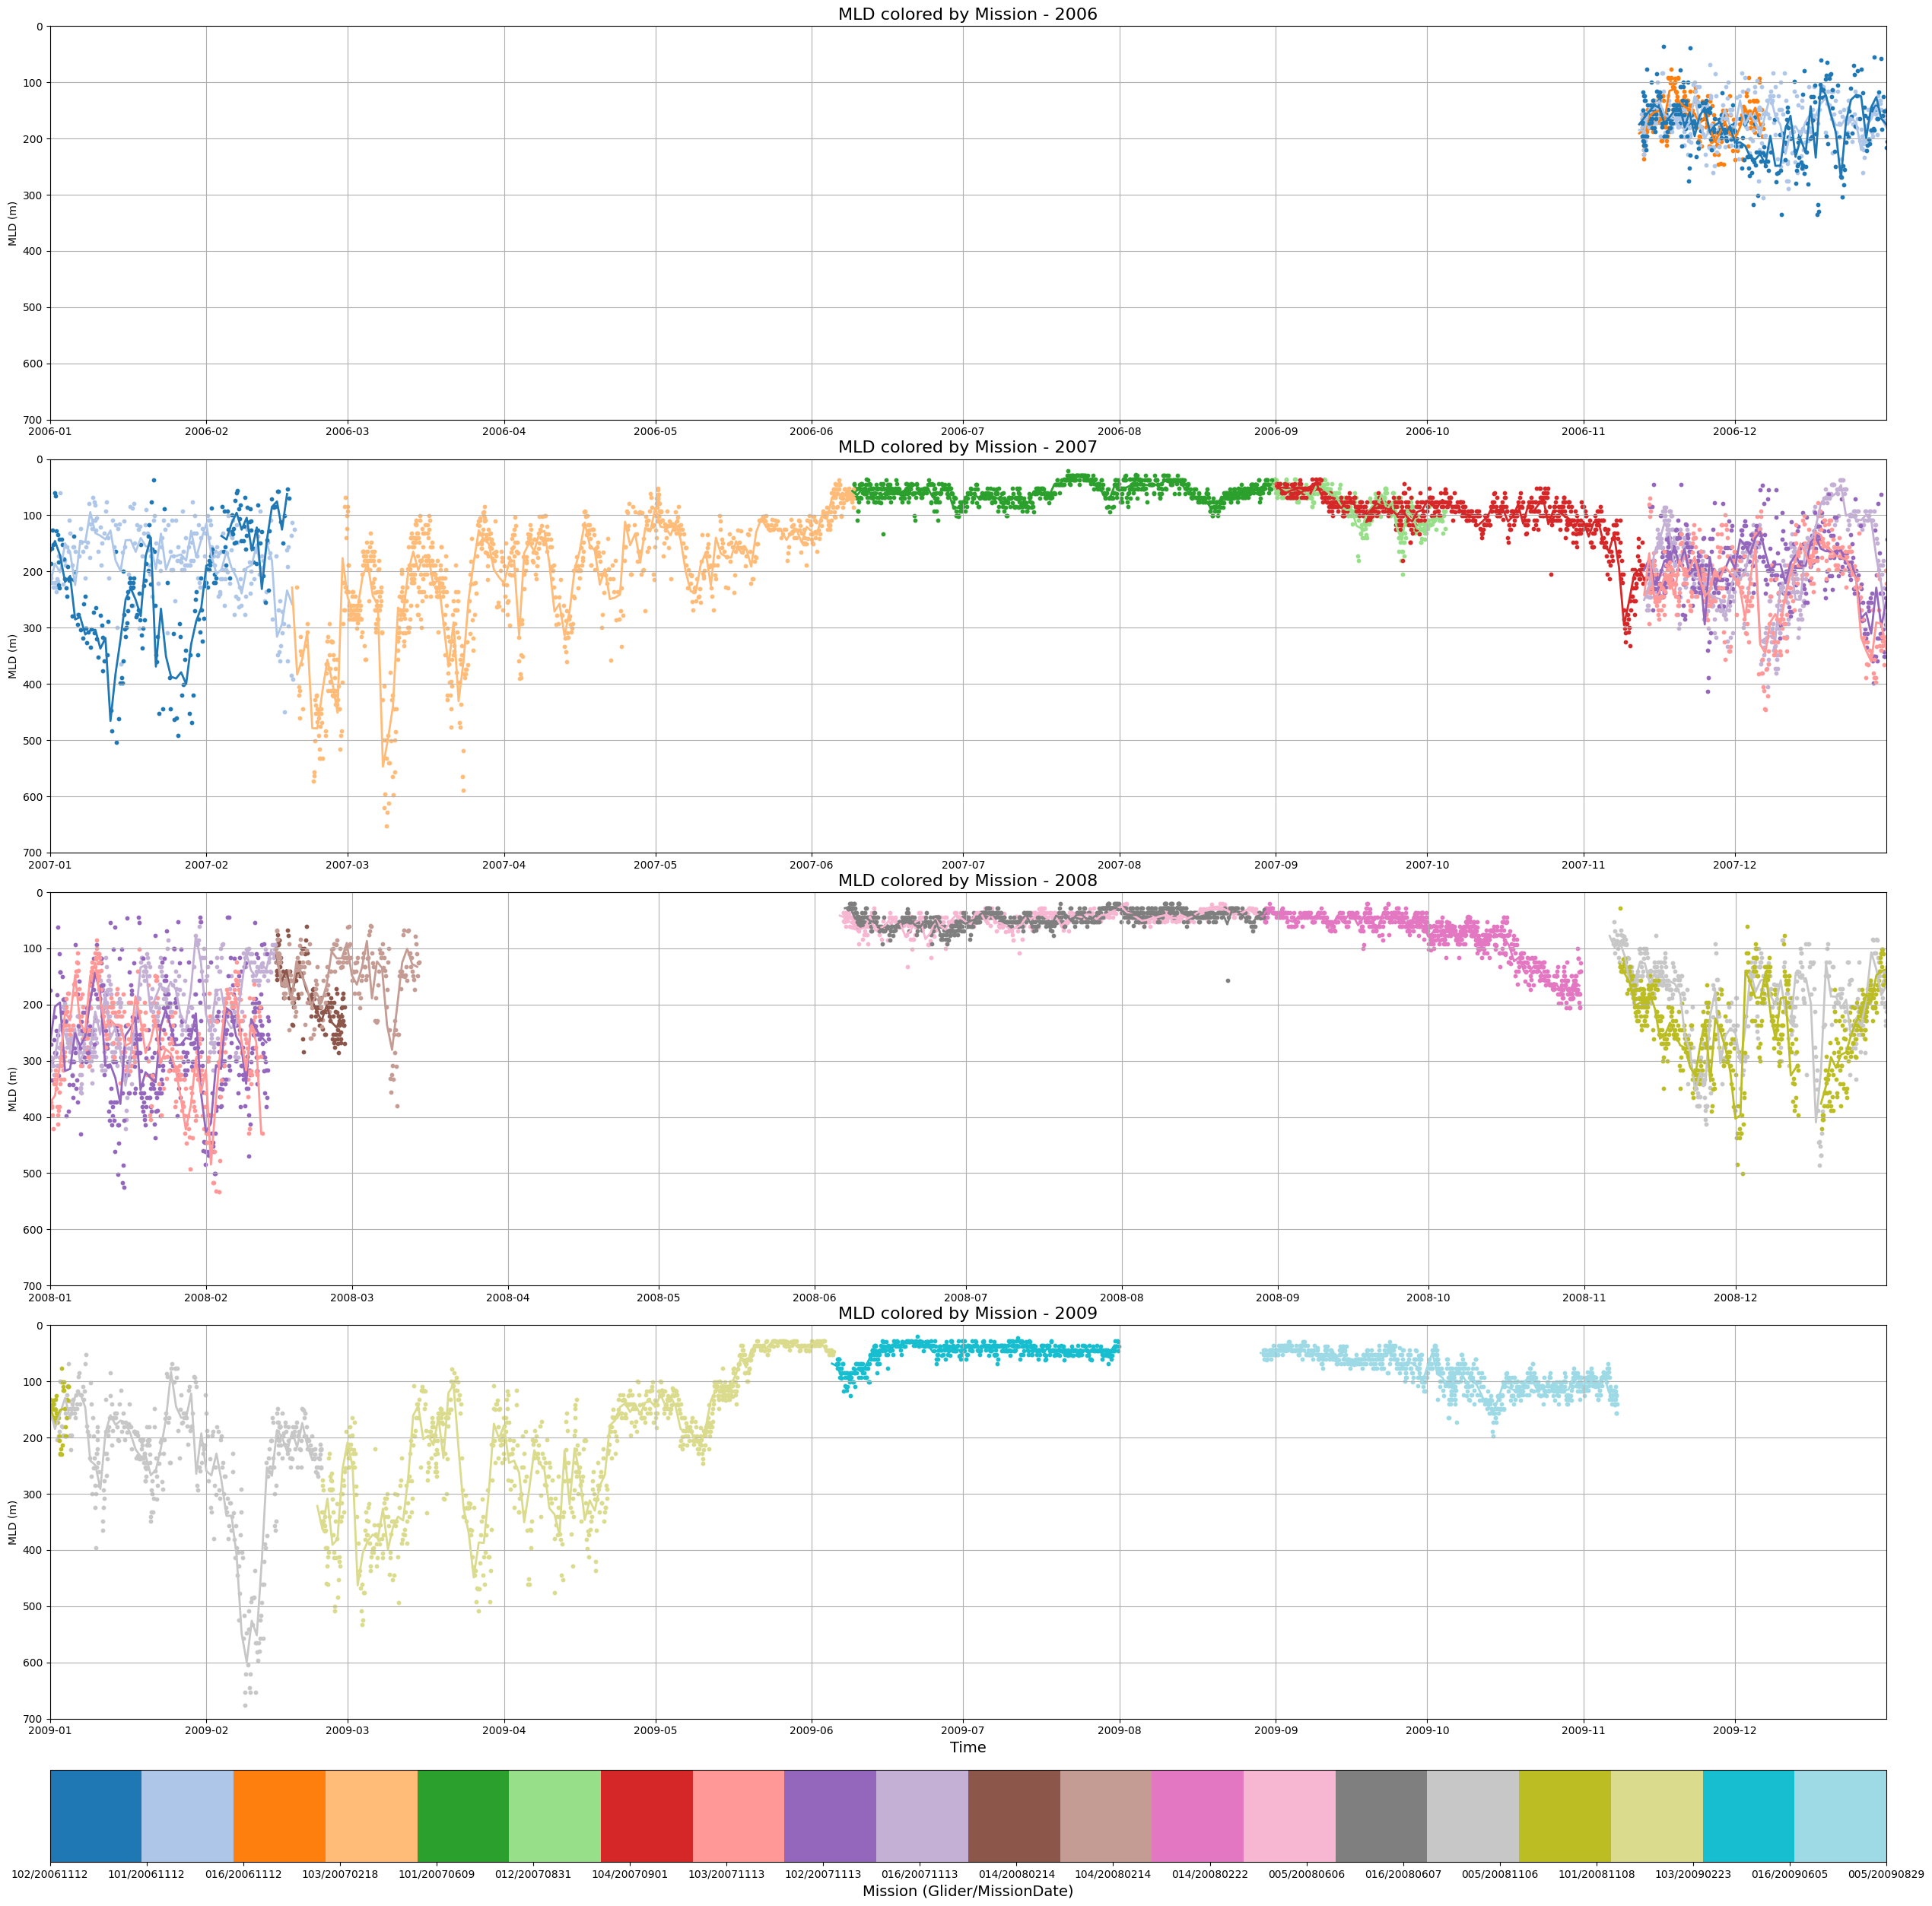

In [200]:
fig = plotting.plot_var_from_mld(mld_ds_list, 'MLD', [2006,2007,2008,2009], rolling_str='1d')

## Open ERA5 data to match with glider data

In [202]:
ERA5_basepath = '/Users/tillmoritz/Desktop/Master_thesis/Data/ERA-5/'

In [203]:
ds_ERA5 = xr.open_dataset(ERA5_basepath + '/ERA5_all_winds_fluxes_waves.nc')

In [222]:
for i in range(len(mld_ds_list)):
    print(f"Processing glidermission: {str(mld_ds_list[i].GLIDER_MISSION[0].values)}")
    mld_ds_list[i] = tools.match_era5_to_mld(mld_ds_list[i], ds_ERA5,lon_range=0.25,lat_range=0.25)

Processing glidermission: 005/20080606


Matching ERA5 to MLD: 100%|██████████| 770/770 [00:04<00:00, 186.60it/s]


Processing glidermission: 005/20090829


Matching ERA5 to MLD: 100%|██████████| 920/920 [00:04<00:00, 200.02it/s]


Processing glidermission: 005/20081106


...

Matching ERA5 to MLD: 100%|██████████| 954/954 [00:04<00:00, 193.48it/s]


Processing glidermission: 104/20070901


Matching ERA5 to MLD: 100%|██████████| 740/740 [00:03<00:00, 189.23it/s]


Processing glidermission: 104/20080214


Matching ERA5 to MLD: 100%|██████████| 224/224 [00:01<00:00, 190.57it/s]


In [223]:
importlib.reload(tools)
for i in range(len(mld_ds_list)):
    print(f"Processing glidermission: {str(mld_ds_list[i].GLIDER_MISSION[0].values)}")
    mld_ds_list[i] = tools.dissipation_bouyancy_flux(mld_ds_list[i])
    mld_ds_list[i] = tools.dissipation_wind_stress(mld_ds_list[i])

Processing glidermission: 005/20080606
Processing glidermission: 005/20090829
Processing glidermission: 005/20081106
Processing glidermission: 012/20070831
Processing glidermission: 014/20080214
Processing glidermission: 014/20080222
Processing glidermission: 016/20061112
Processing glidermission: 016/20071113
Processing glidermission: 016/20080607
Processing glidermission: 016/20090605
Processing glidermission: 101/20061112
Processing glidermission: 101/20070609
Processing glidermission: 101/20081108
Processing glidermission: 102/20061112
Processing glidermission: 102/20071113
Processing glidermission: 103/20070218
Processing glidermission: 103/20071113
Processing glidermission: 103/20090223
Processing glidermission: 104/20070901
Processing glidermission: 104/20080214


In [237]:
mld_ds_list[0]

<xarray.Dataset> Size: 197kB
Dimensions:                      (TIME: 770)
Coordinates:
  * TIME                         (TIME) datetime64[ns] 6kB 2008-06-06T18:12:0...
    valid_time                   (TIME) datetime64[ns] 6kB 2008-06-06T18:00:0...
Data variables: (12/31)
    PROFILE_NUMBER               (TIME) float64 6kB ...
    MLD                          (TIME) float64 6kB 36.4 36.0 52.2 ... nan 36.6
    LONGITUDE                    (TIME) float64 6kB -8.275 -8.276 ... -6.052
    LATITUDE                     (TIME) float64 6kB 61.42 61.42 ... 63.69 63.69
    GLIDER_MISSION               (TIME) <U12 37kB ...
    GLIDER                       (TIME) <U3 9kB ...
    ...                           ...
    U_STAR                       (TIME) float64 6kB 0.001832 0.001832 ... 0.0158
    TAU                          (TIME) float32 3kB 0.003446 0.003446 ... 0.2563
    h_s                          (TIME) float64 6kB 90.06 90.06 ... nan 10.51
    H_S                          (TIME) float64 6kB 136.0 136.0 ... nan 13.77
    epsilon_tau                  (TIME) float64 6kB 0.0 0.0 ... nan 2.765e-05
    EPSILON_TAU                  (TIME) float64 6kB 0.0 0.0 ... nan 9.631e-06
Attributes:
    longitude_range_used:  ±0.25°
    latitude_range_used:   ±0.25°

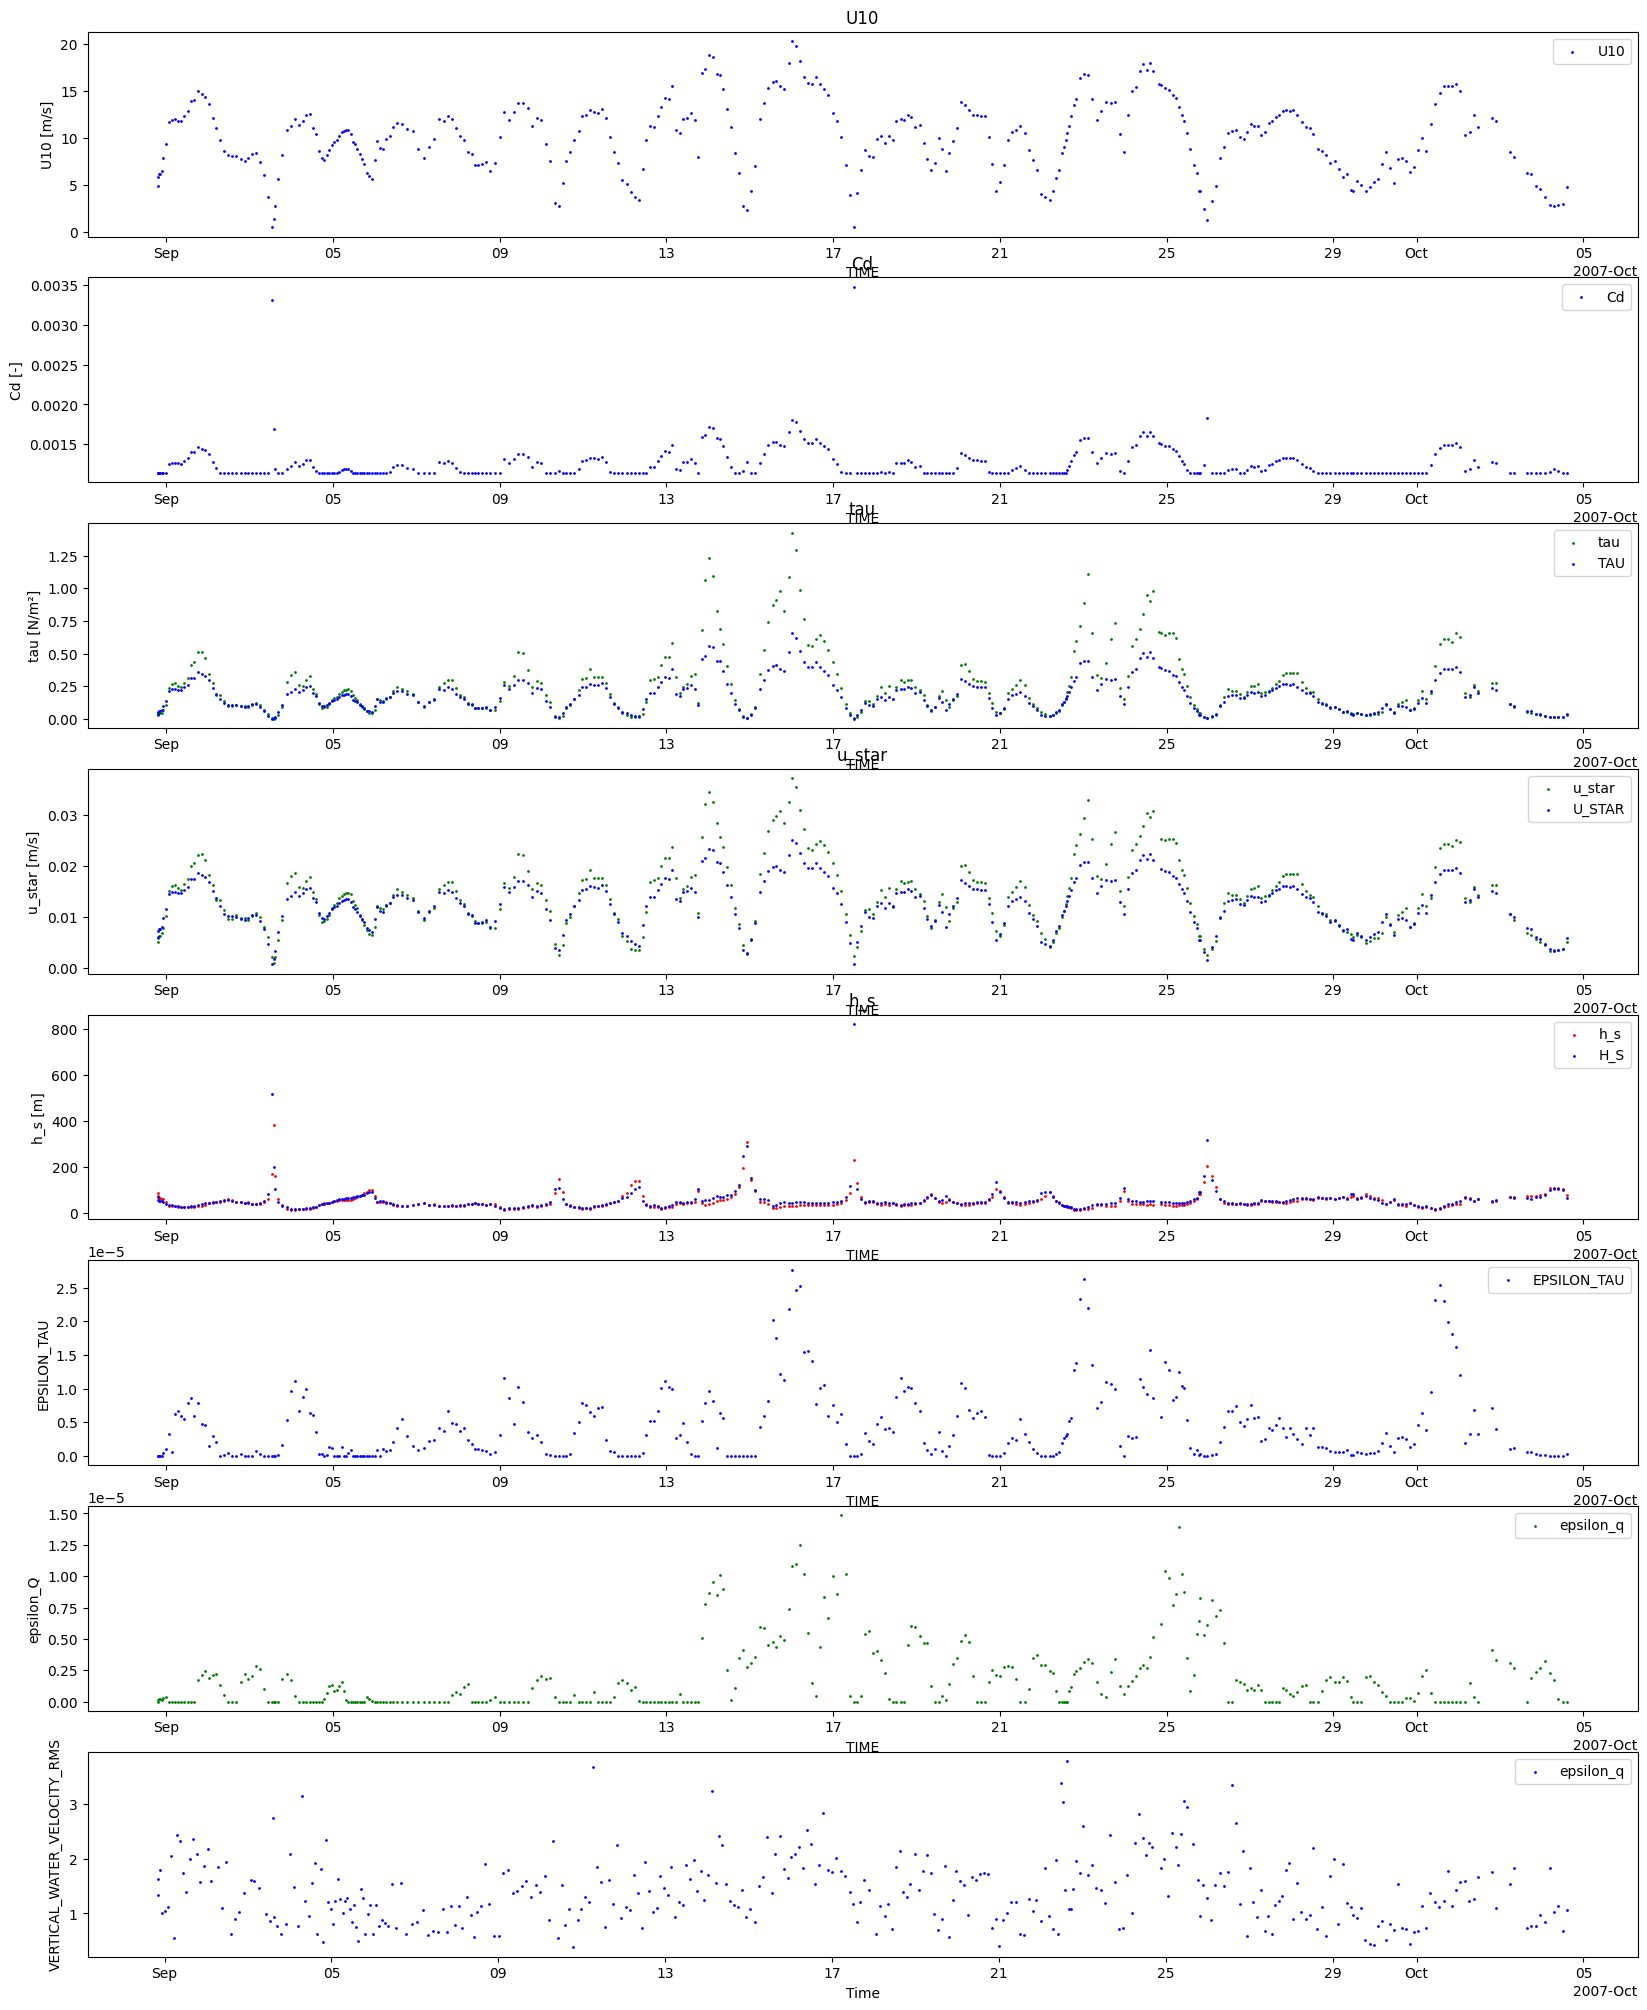

In [253]:
# Plot h_s, T, and 1/u_star for mld_ds in three subplots as scatter plots
mission = 3
mld_ds = mld_ds_list[mission]
fig, ax = plt.subplots(8, 1, figsize=(20, 25))

U10 = np.sqrt(mld_ds['u10']**2 + mld_ds['v10']**2)
Cd = tools.drag_coefficient_trenberth1990(U10.values)

U10.plot.scatter(label='U10', ax=ax[0], s=1, facecolors='b', edgecolors='b')
## add Cd to mld_ds with TIME as index
mld_ds['Cd'] = (('TIME'), Cd)
mld_ds['Cd'].plot.scatter(label='Cd', ax=ax[1], s=1, facecolors='b', edgecolors='b')
mld_ds['tau'].plot.scatter(label='tau', ax=ax[2], s=1, facecolors='g', edgecolors='g')
mld_ds['TAU'].plot.scatter(label='TAU', ax=ax[2], s=1, facecolors='b', edgecolors='b')
mld_ds['u_star'].plot.scatter(label='u_star', ax=ax[3], s=1, facecolors='g', edgecolors='g')
mld_ds['U_STAR'].plot.scatter(label='U_STAR', ax=ax[3], s=1, facecolors='b', edgecolors='b')
mld_ds['h_s'].plot.scatter(label='h_s', ax=ax[4], s=1, facecolors='r', edgecolors='r')
mld_ds['H_S'].plot.scatter(label='H_S', ax=ax[4], s=1, facecolors='b', edgecolors='b')
#mld_ds['epsilon_tau'].plot.scatter(label='epsilon_tau', ax=ax[5], s=1, facecolors='g', edgecolors='g')
mld_ds['EPSILON_TAU'].plot.scatter(label='EPSILON_TAU', ax=ax[5], s=1, facecolors='b', edgecolors='b')
mld_ds['epsilon_Q'].plot.scatter(label='epsilon_q', ax=ax[6], s=1, facecolors='g', edgecolors='g')
mld_ds['VERTICAL_WATER_VELOCITY_RMS'].plot.scatter(label='epsilon_q', ax=ax[7], s=1, facecolors='b', edgecolors='b')
ax[0].set_title('U10')
ax[1].set_title('Cd')
ax[2].set_title('tau')
ax[3].set_title('u_star')
ax[4].set_title('h_s')
ax[0].set_ylabel('U10 [m/s]')
ax[1].set_ylabel('Cd [-]')
ax[2].set_ylabel('tau [N/m²]')
ax[3].set_ylabel('u_star [m/s]')
ax[4].set_ylabel('h_s [m]')
ax[-1].set_xlabel('Time')
[ax.legend() for ax in ax]

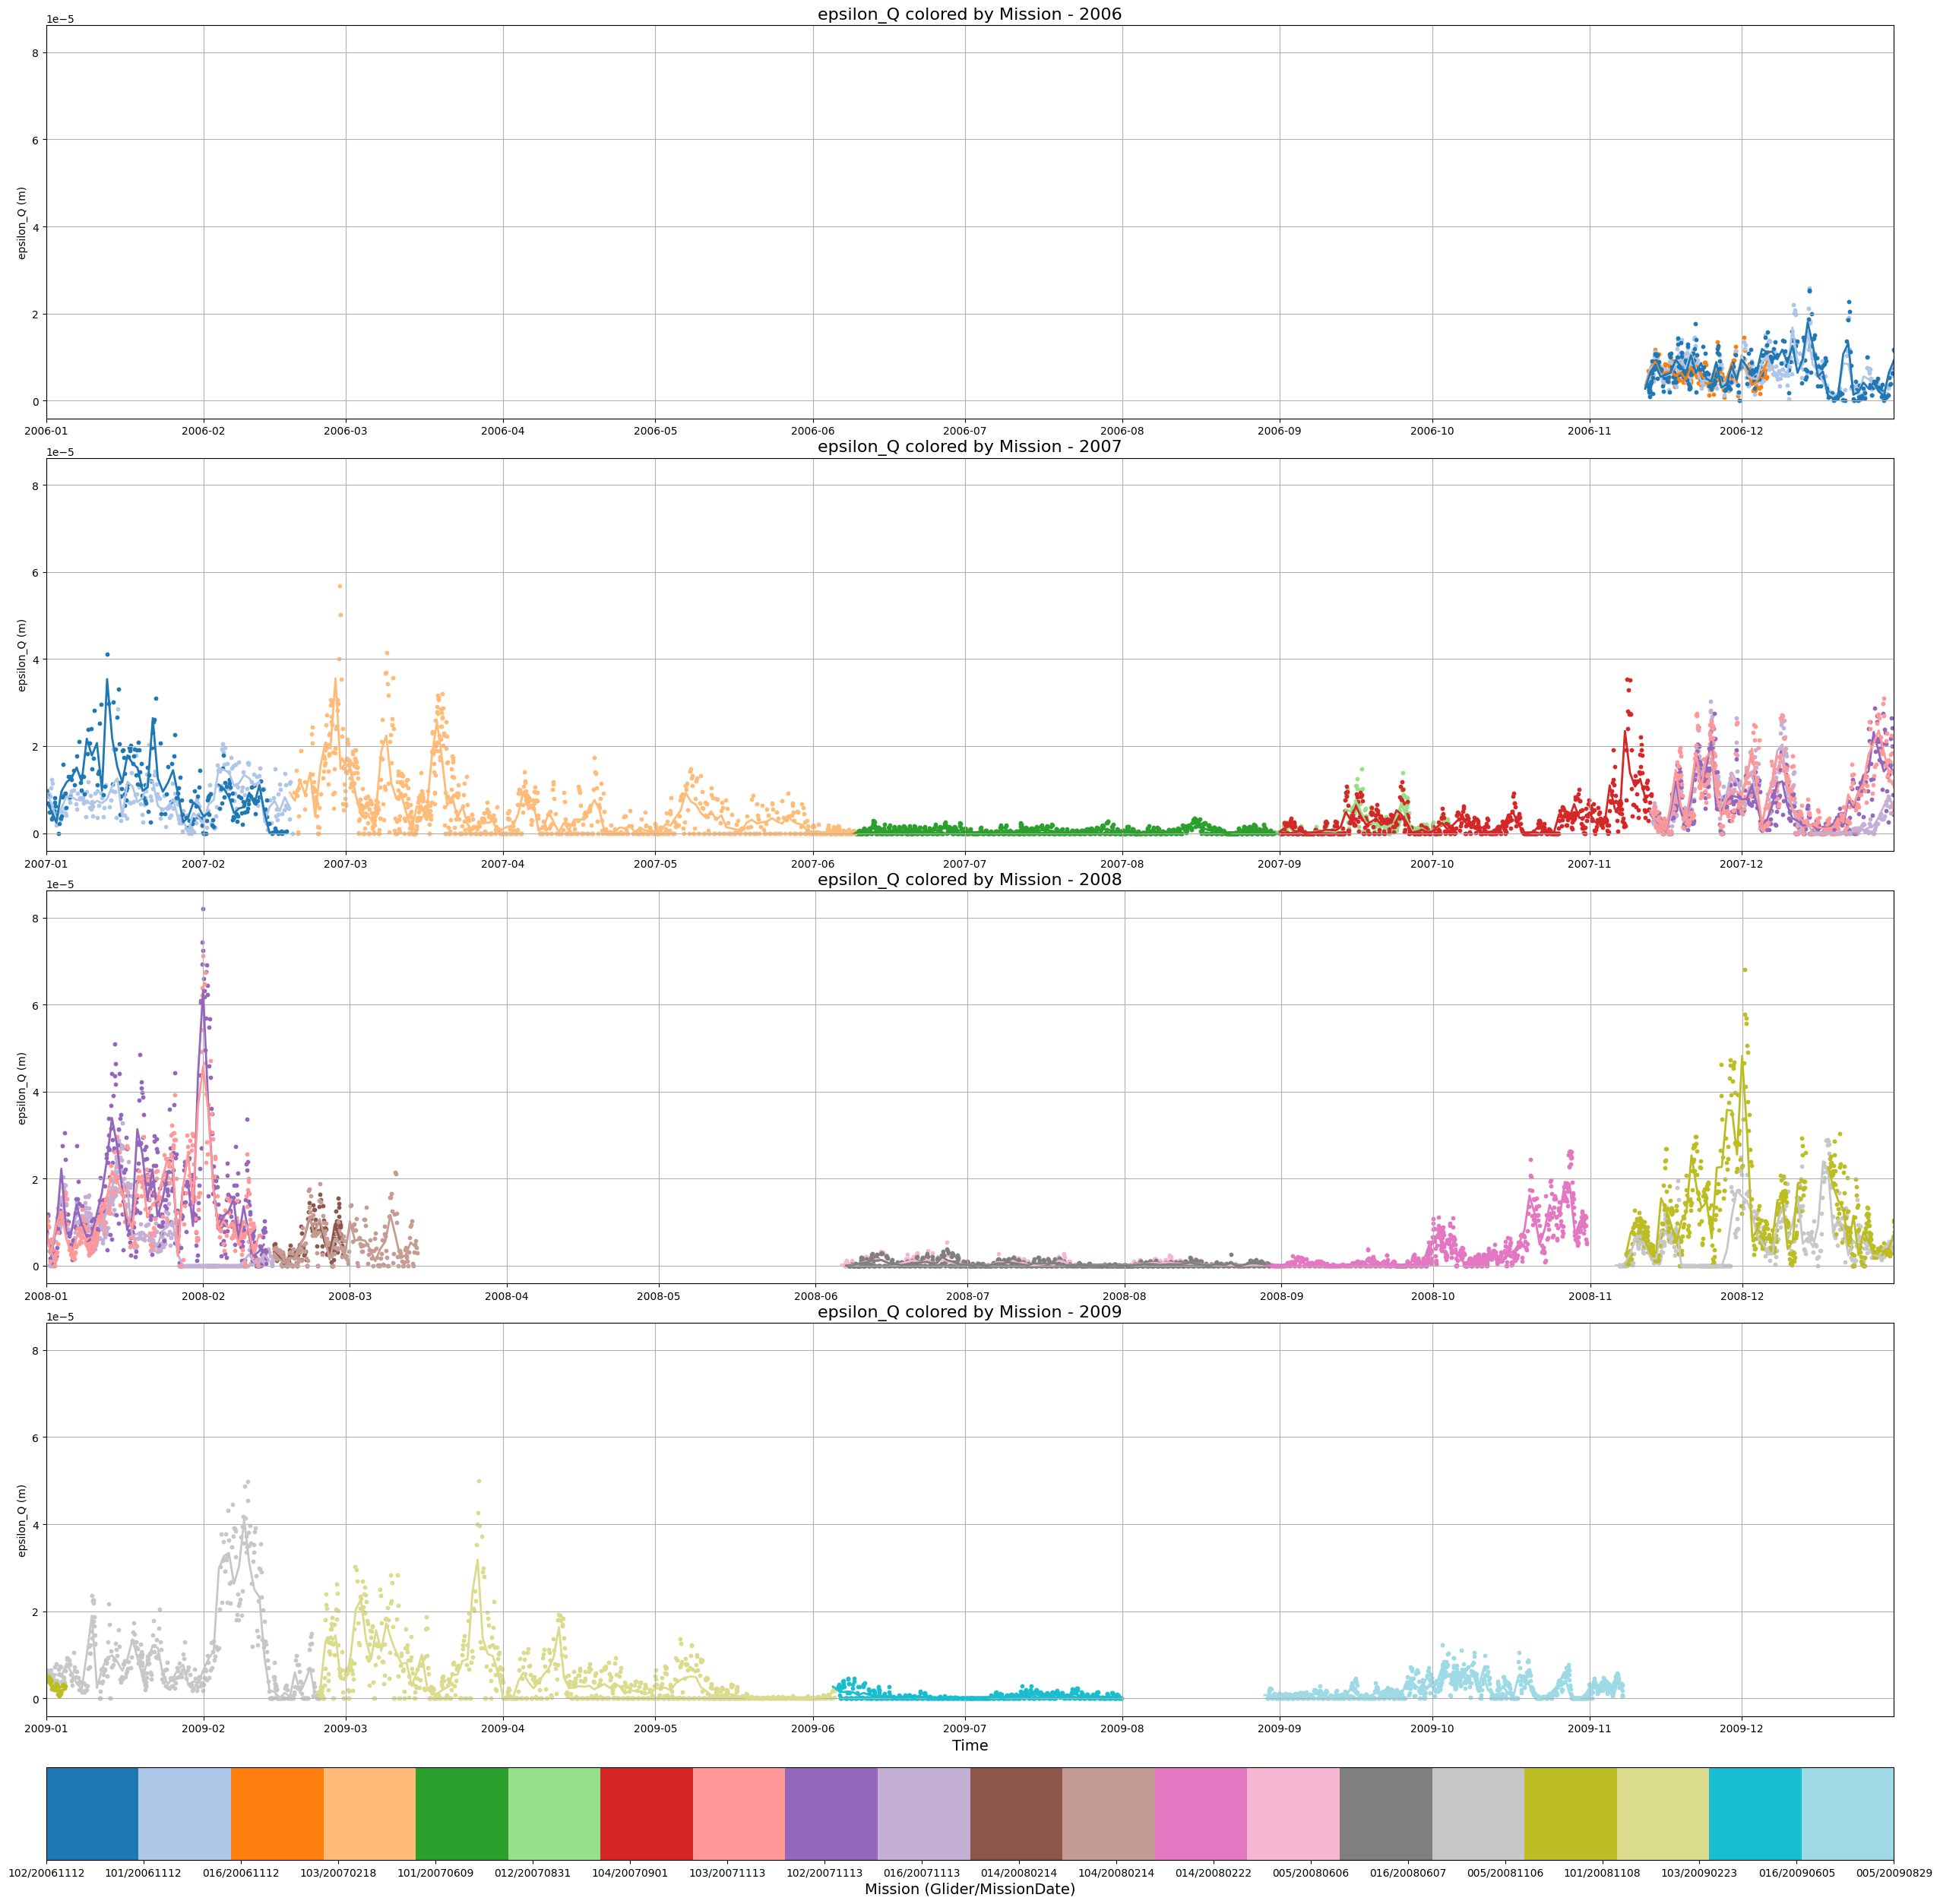

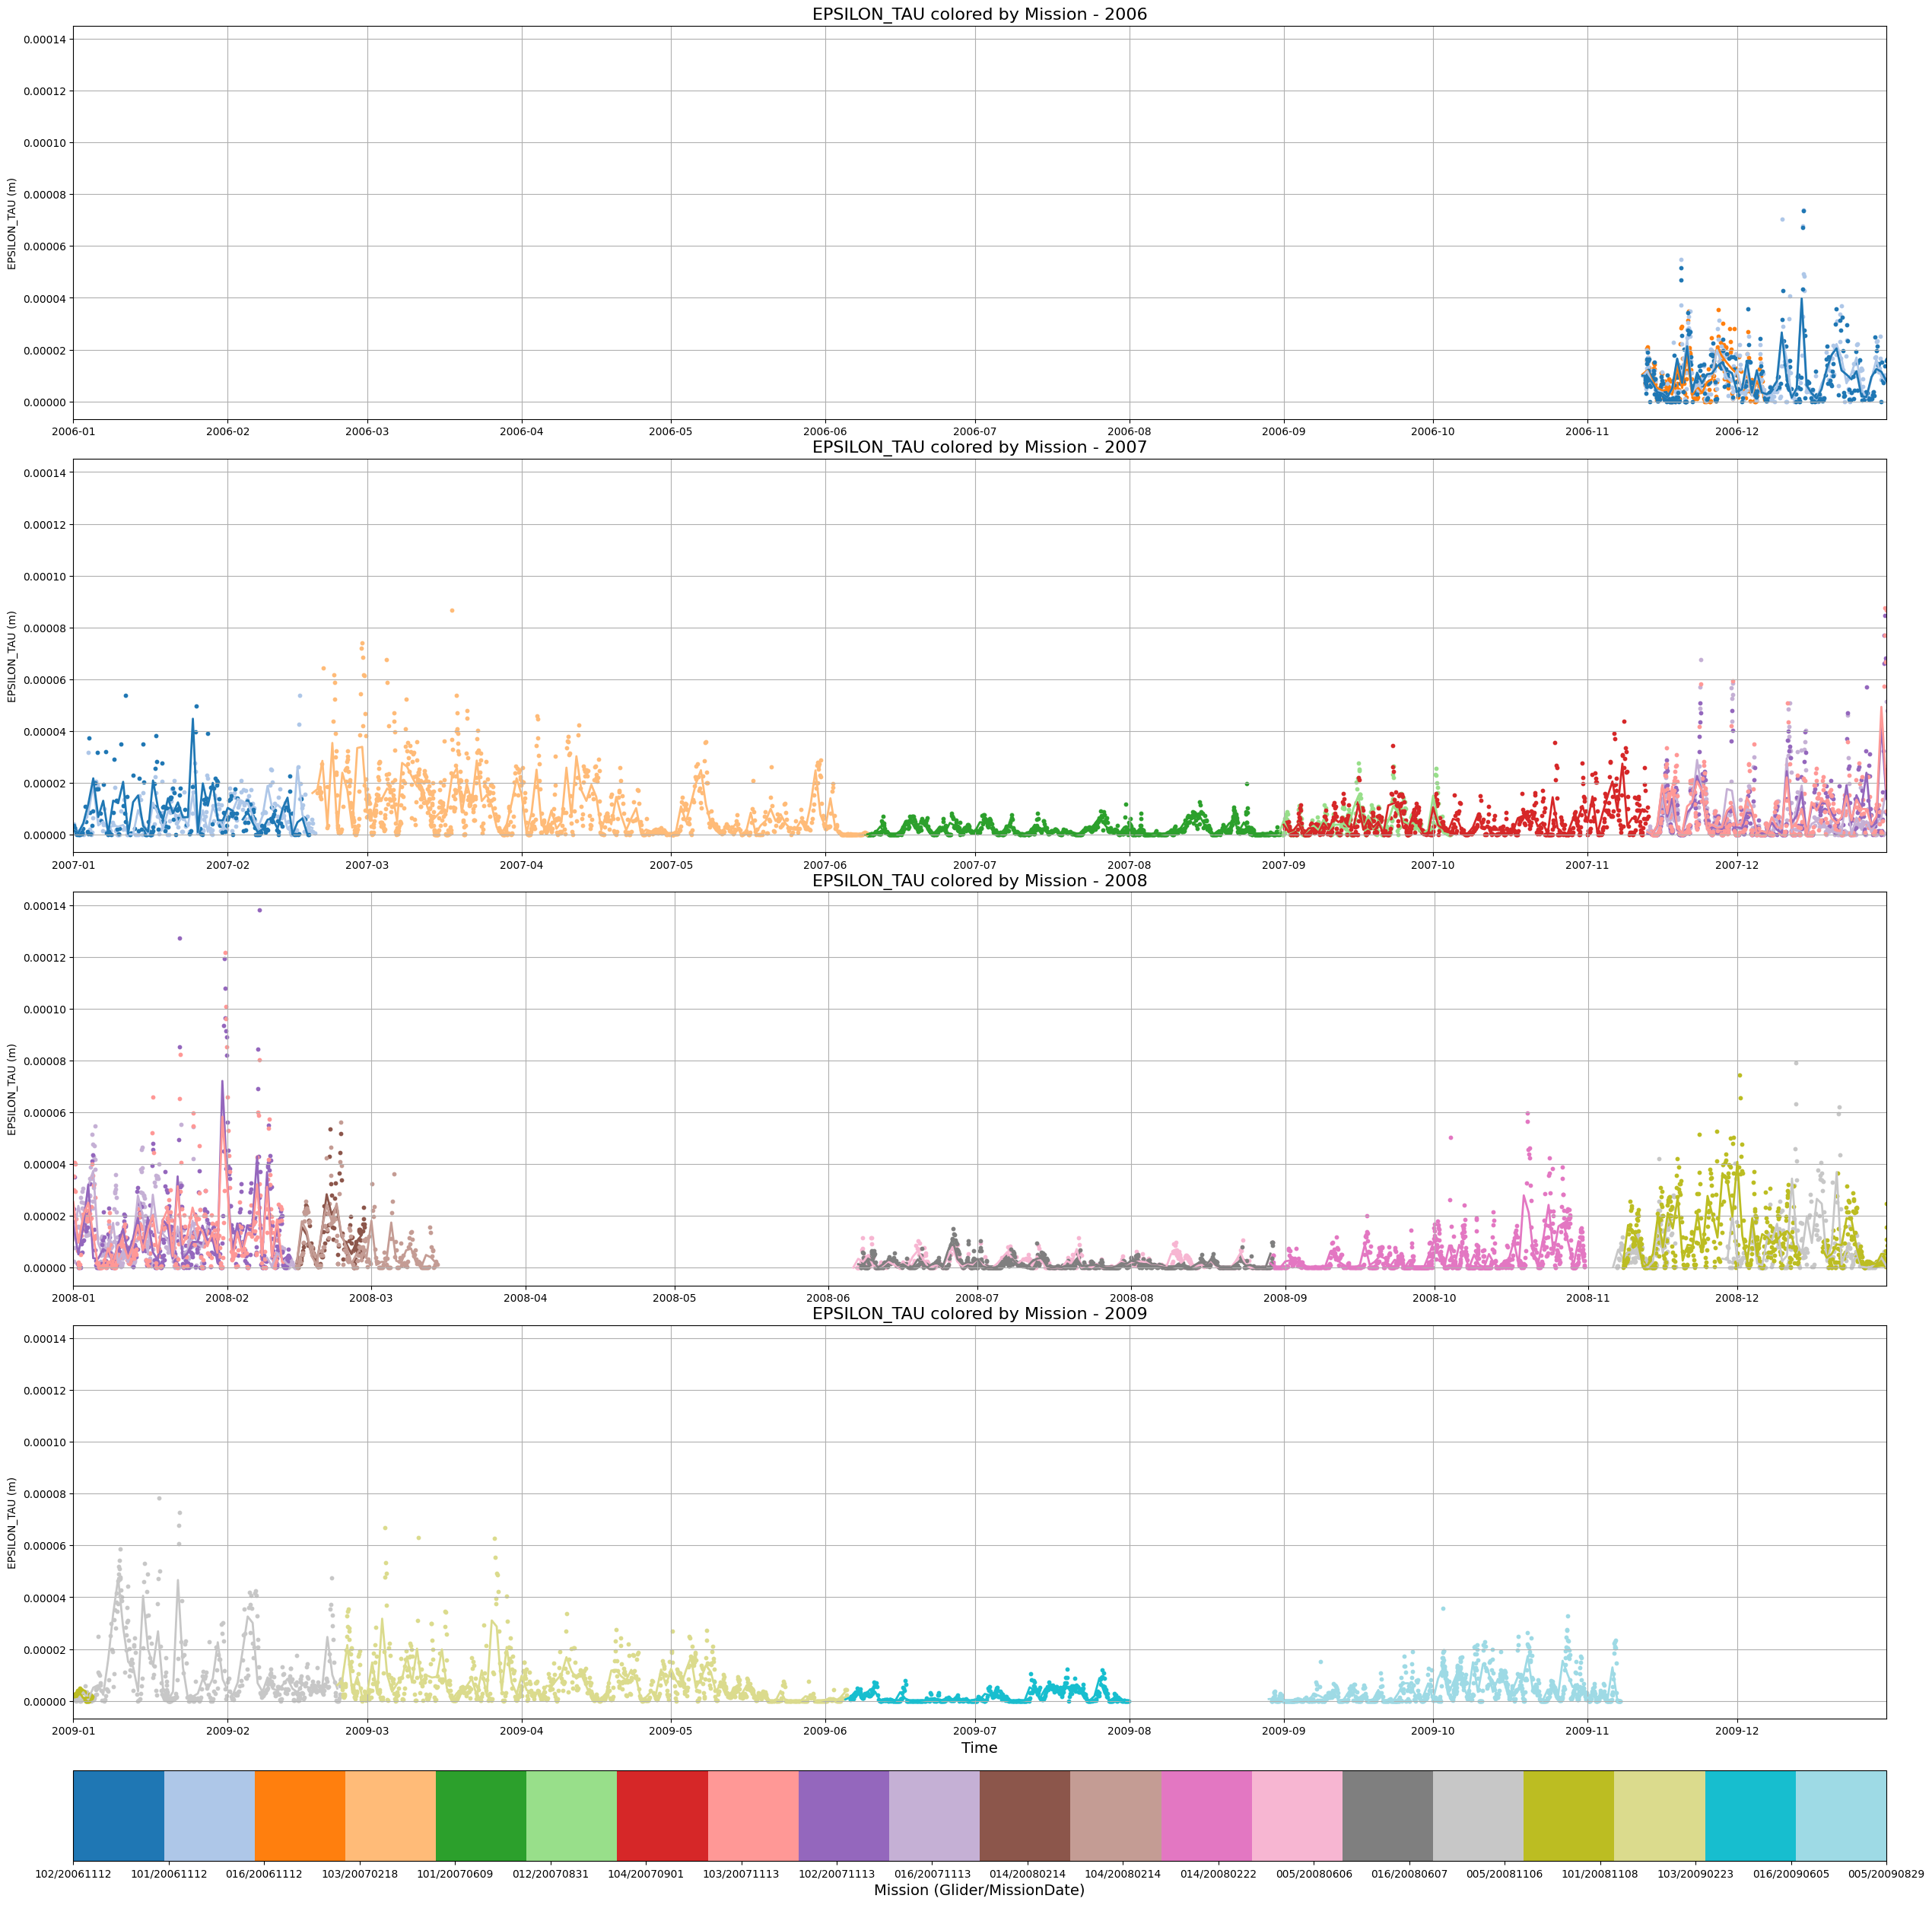

In [239]:
fig = plotting.plot_var_from_mld(mld_ds_list, 'epsilon_Q', [2006,2007,2008,2009], rolling_str='1d')
fig = plotting.plot_var_from_mld(mld_ds_list, 'EPSILON_TAU', [2006,2007,2008,2009], rolling_str='1d')

Text(0.5, 1.0, 'All glider missions')

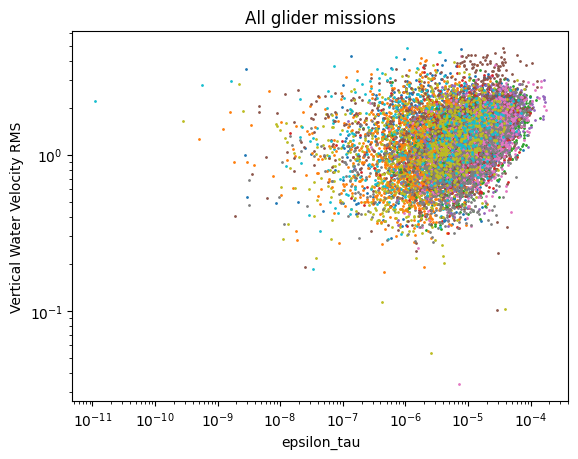

In [250]:
for ds in mld_ds_list:
    plt.scatter(ds.epsilon_Q + ds.EPSILON_TAU, ds.VERTICAL_WATER_VELOCITY_RMS, s=1)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('epsilon_tau')
    plt.ylabel('Vertical Water Velocity RMS')
    plt.grid()
plt.title(f"All glider missions")

Text(0.5, 1.0, 'Glider mission: 016/20090605')

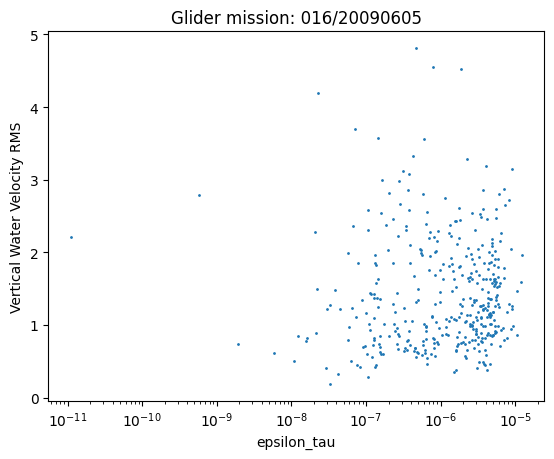

In [244]:
mission = 9
mld_ds = mld_ds_list[mission]

plt.scatter(mld_ds.EPSILON_TAU, mld_ds.VERTICAL_WATER_VELOCITY_RMS, s=1)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('epsilon_tau')
plt.ylabel('Vertical Water Velocity RMS')
plt.title(f"Glider mission: {str(mld_ds.GLIDER_MISSION[0].values)}")


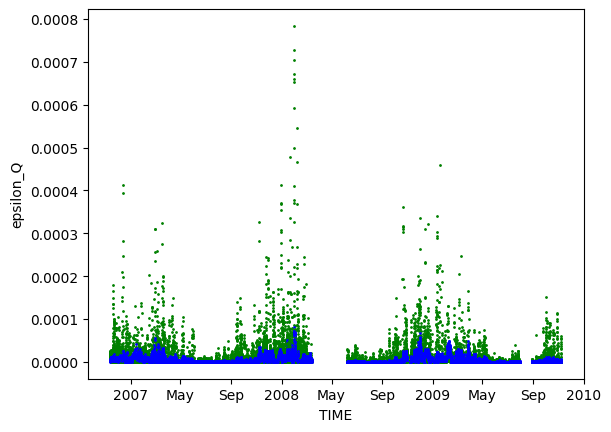

In [232]:
for ds in mld_ds_list:
    ds['epsilon_tau'].plot.scatter(label='epsilon_tau', s=1, facecolors='g', edgecolors='g')
    ds['epsilon_Q'].plot.scatter(label='epsilon_Q', s=1, facecolors='b', edgecolors='b')

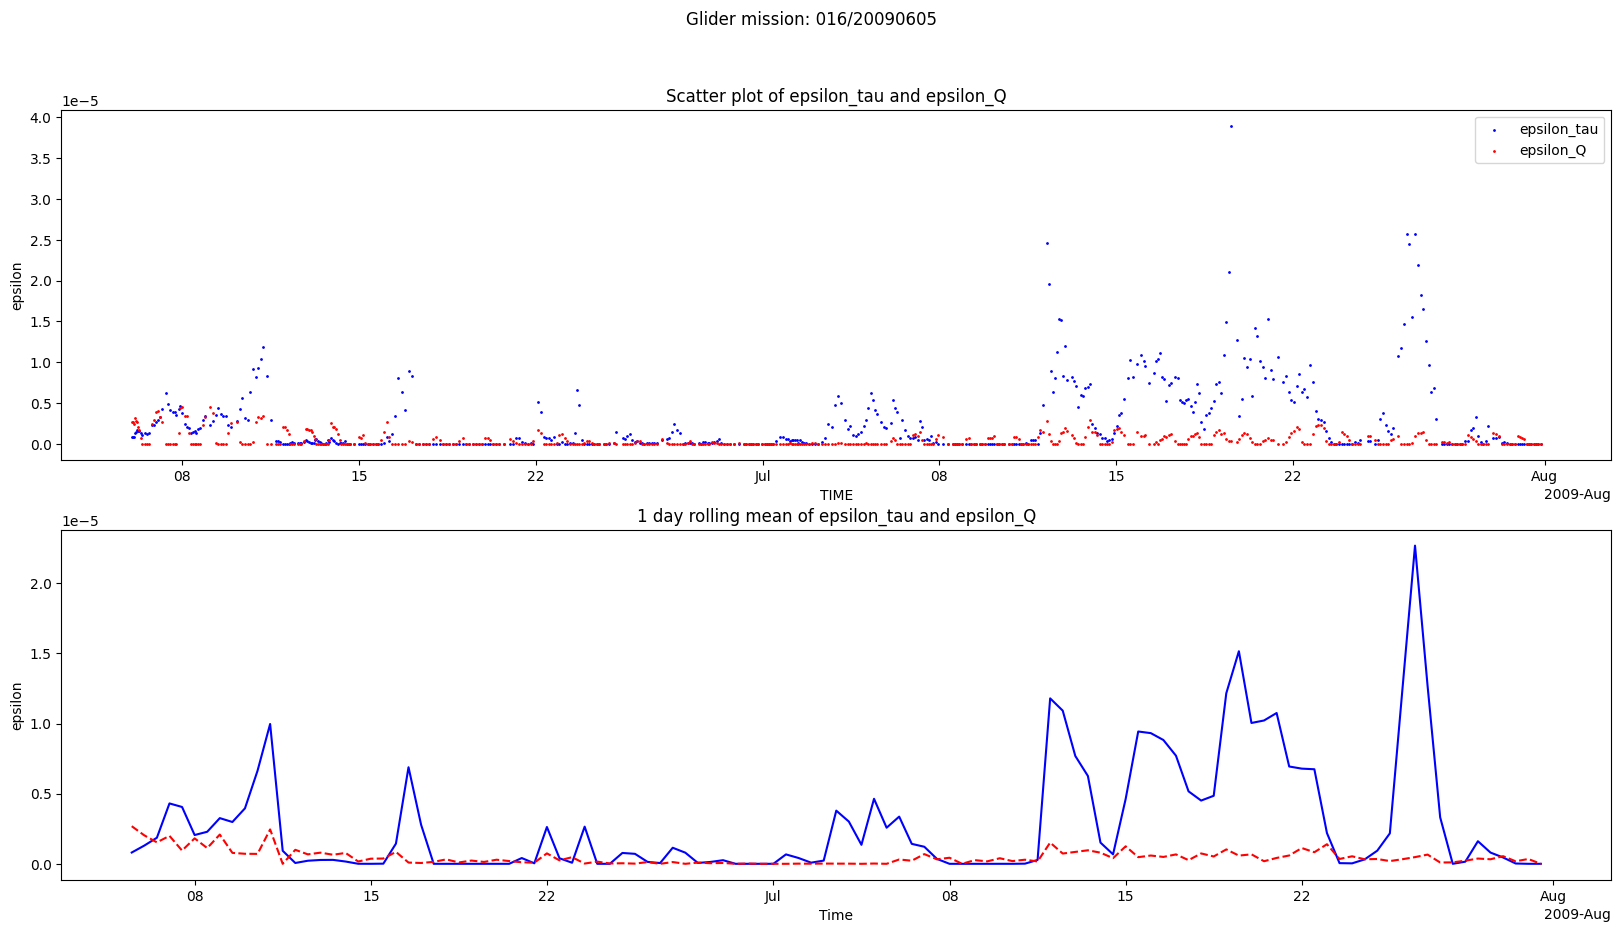

In [229]:
### plot MLD and h_s as function of time in one scatter plot
mission = 9
mld_ds = mld_ds_list[mission]
mld_rolling = mld_ds.resample(TIME='12h').mean()
fig, ax = plt.subplots(2, 1,figsize=(20, 10))
fig.suptitle(f"Glider mission: {str(mld_ds.GLIDER_MISSION[0].values)}")
mld_ds['epsilon_tau'].plot.scatter(label='epsilon_tau', ax=ax[0],s = 1, facecolors='b', edgecolors='b')
mld_ds['epsilon_Q'].plot.scatter(label='epsilon_Q', ax=ax[0], s=1, facecolors='r', edgecolors='r')
### plot also 1 day rolling mean
mld_rolling['epsilon_tau'].plot(label='epsilon_tau', ax=ax[1], color='b')
mld_rolling['epsilon_Q'].plot(label='epsilon_Q', ax=ax[1], color='r', linestyle='--')
ax[0].set_title('Scatter plot of epsilon_tau and epsilon_Q')
ax[1].set_title('1 day rolling mean of epsilon_tau and epsilon_Q')
ax[0].set_ylabel('epsilon')
ax[1].set_ylabel('epsilon')
ax[1].set_xlabel('Time')
ax[0].legend()

import xarray as xr
#from tqdm import tqdm
importlib.reload(tools)

mld_ds_list = []
method = 'CR'
threshold = -3
use_bins = True
binning = 8

for glider in tqdm(config['gliders'], desc="Processing gliders"):
    glider_name = glider['name']
    
    for mission in glider['missions']:
        print(f"Processing glidermission: {mission['folder']}")
        folder = mission.get('folder')
        if folder == 'no folder':
            continue

        file_path = f"{destination_folder}/{folder}/all_data_OG1.nc"
        ds = xr.open_dataset(file_path)

        if method == 'CR':
            variable = 'SIGMA_1'
        elif method == 'threshold':
            variable = 'SIGMA_T'
        mld= tools.compute_mld(ds,variable=variable,method=method,threshold= threshold,ref_depth=10,use_bins=use_bins,binning=binning)

        mld = tools.root_mean_square_in_mld(ds, mld, 'VERTICAL_WATER_VELOCITY',min_depth=40)
        mld = tools.mean_in_mld(ds, mld, ['SIGTHETA', 'TEMP', 'PSAL'])

        # Add metadata
        mld['GLIDER_MISSION'] = folder
        mld['GLIDER'] = glider_name

        # Set TIME as index and convert to xarray.Dataset
        mld.set_index('TIME', inplace=True)
        mld_ds = xr.Dataset.from_dataframe(mld)

        mld_ds_list.append(mld_ds)

# Concatenate all MLD datasets along TIME dimension
mld_ds = xr.concat(mld_ds_list, dim='TIME')
mld_ds = mld_ds.sortby('TIME')
### somehow some time stamps are from 1970
mld_ds = mld_ds.sel(TIME=slice('2006-01-01', '2009-12-31'))

### delete nan mld values
mld_ds = mld_ds.where(mld_ds.MLD.notnull(), drop=True)
